In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.data import DataManager
from utils.tools import BENCHMARKS, RISK_ANALYSIS

from utils.analysis.risk_metrics import (
    VarEsAnalyzer, VarEsReporter,
    RatioAnalyzer, RatioReporter,
    DistributionAnalyzer, DistributionReporter,
    BenchmarkAnalyzer, BenchmarkReporter,
    DrawdownAnalyzer, DrawdownReporter,
    CorrelationAnalyzer, CorrelationReporter
)

from utils.visualizations import (
    DrawdownVisualizer, 
    DistributionVisualizer, 
    VarEsVisualizer, 
    RatioVisualizer, 
    BenchmarkVisualizer
)

from utils.analysis.risk_metrics.components import calculate_portfolio_returns

In [15]:
TICKERS = ["META", "AAPL", "GOOGL", "NVDA", "MSFT"] 
BENCHMARK_NAME = "SP500" 
START_DATE = "2020-01-01" 
END_DATE = "2024-12-31"

In [16]:
WEIGHTS = np.ones(len(TICKERS)) / len(TICKERS)

# Constantes desde config
RISK_FREE_RATE = RISK_ANALYSIS['risk_free_rate']
ANNUAL_FACTOR = RISK_ANALYSIS['annual_factor']
DEFAULT_CONFIDENCE = RISK_ANALYSIS['default_confidence_level']
CONFIDENCE_LEVELS = RISK_ANALYSIS['default_confidence_levels']
ROLLING_WINDOW = RISK_ANALYSIS['rolling']['default_window']
MC_SIMULATIONS = RISK_ANALYSIS['monte_carlo']['n_simulations']
MC_SEED = RISK_ANALYSIS['monte_carlo']['seed']

In [17]:
data_manager = DataManager()

assets_prices, benchmark_prices = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name=BENCHMARK_NAME,
    start_date=START_DATE,
    end_date=END_DATE
)

returns = assets_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31
Período: 2020-01-01 → 2024-12-31
Portafolio descargado: 5 activos + benchmark


In [18]:
# Analyzers
var_es_analyzer = VarEsAnalyzer(annual_factor=ANNUAL_FACTOR)
ratio_analyzer = RatioAnalyzer(annual_factor=ANNUAL_FACTOR)
dist_analyzer = DistributionAnalyzer()
benchmark_analyzer = BenchmarkAnalyzer(annual_factor=ANNUAL_FACTOR)
drawdown_analyzer = DrawdownAnalyzer(annual_factor=ANNUAL_FACTOR)
correlation_analyzer = CorrelationAnalyzer()

# Reporters
var_es_reporter = VarEsReporter(var_es_analyzer)
ratio_reporter = RatioReporter(ratio_analyzer)
dist_reporter = DistributionReporter(dist_analyzer)
benchmark_reporter = BenchmarkReporter(benchmark_analyzer)
drawdown_reporter = DrawdownReporter(drawdown_analyzer)
correlation_reporter = CorrelationReporter(correlation_analyzer)

# Visualizers (crear solo cuando se necesiten)
ratio_viz = RatioVisualizer(annual_factor=ANNUAL_FACTOR)
benchmark_viz = BenchmarkVisualizer(annual_factor=ANNUAL_FACTOR)
dist_viz = DistributionVisualizer()
drawdown_viz = DrawdownVisualizer()
var_es_viz = VarEsVisualizer(annual_factor=ANNUAL_FACTOR)

In [19]:
portfolio_returns = calculate_portfolio_returns(returns, WEIGHTS)

# Métricas básicas
annual_return = portfolio_returns.mean() * ANNUAL_FACTOR
annual_vol = portfolio_returns.std() * np.sqrt(ANNUAL_FACTOR)
sharpe = (annual_return - RISK_FREE_RATE) / annual_vol

print("RESUMEN RÁPIDO DEL PORTAFOLIO".center(70))
print(f"  Retorno anual:           {annual_return*100:>8.2f}%")
print(f"  Volatilidad anual:       {annual_vol*100:>8.2f}%")
print(f"  Sharpe Ratio:            {sharpe:>8.3f}")
print(f"  Retorno/Riesgo:          {annual_return/annual_vol:>8.3f}")

                    RESUMEN RÁPIDO DEL PORTAFOLIO                     
  Retorno anual:              37.90%
  Volatilidad anual:          32.46%
  Sharpe Ratio:               1.029
  Retorno/Riesgo:             1.168


               VaR y ES - Comparación de Métodos (95%)                
             ANÁLISIS VaR y ES (Nivel de confianza: 95%)              
COMPARACIÓN DE MÉTODOS
Método          VaR Diario      VaR Anual       ES Diario       ES Anual       
Historical        -3.32%       -52.74%        -4.65%       -73.79%
Parametric        -3.21%       -50.98%        -4.07%       -64.53%
Monte_carlo       -3.27%       -51.93%        -4.13%       -65.49%
INTERPRETACIÓN
VaR promedio diario:     -3.27%
ES promedio diario:      -4.28%
Pérdida máxima esperada: -4.28% en un día adverso
  Nivel de riesgo:         Moderado


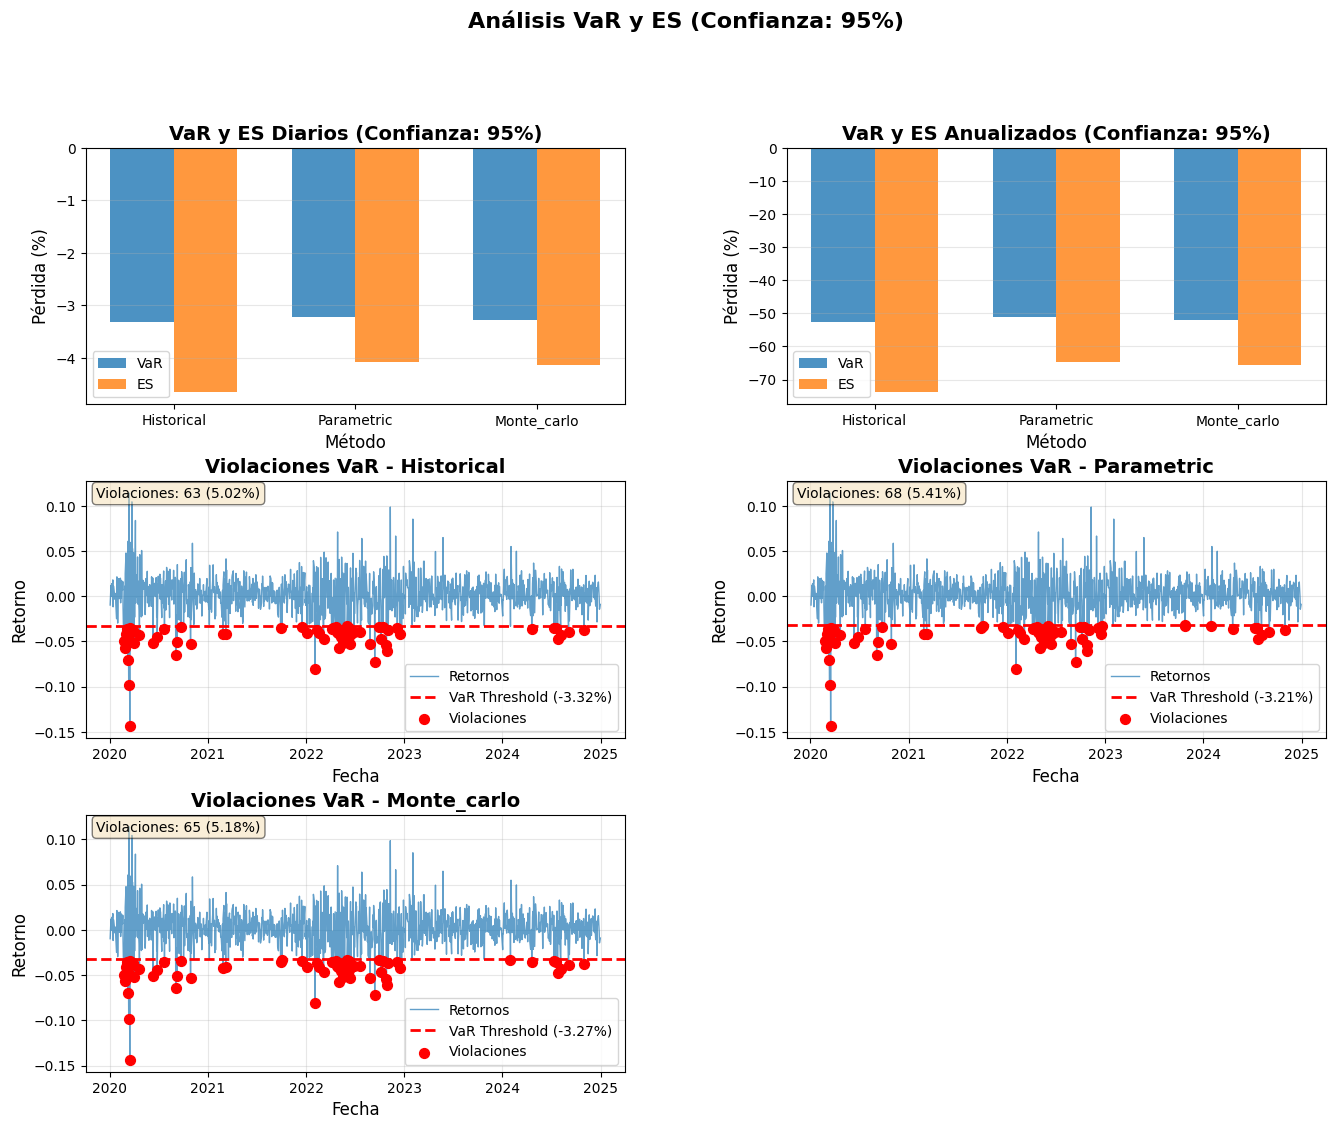

In [20]:
var_es_results = var_es_analyzer.calculate_multi_level(
    returns=returns,
    weights=WEIGHTS,
    confidence_levels=CONFIDENCE_LEVELS,
    n_simulations=MC_SIMULATIONS,
    seed=MC_SEED
)

print("VaR y ES - Comparación de Métodos (95%)".center(70))
comparison_df = var_es_reporter._results_to_dataframe(var_es_results[0.95])
var_es_reporter.print_comparison(comparison_df, confidence_level=0.95)

fig = var_es_viz.plot_var_es_analysis(
    returns=returns,
    weights=WEIGHTS,
    var_es_results=var_es_results,  
    confidence_level=0.95,
    figsize=(16, 12)
)
plt.show()

                    ANÁLISIS DE DRAWDOWN                    
MAX DRAWDOWN
  Magnitud:                  -48.53%
  Fecha:                   2022-11-03 00:00:00
  Duración:                355 días
RATIOS DE DRAWDOWN
  Calmar Ratio:               0.781
  Sterling Ratio:             0.818
RETORNO ANUAL
  Retorno Anual:              37.90%
INTERPRETACIÓN
  Nivel de riesgo:         Muy Alto
  Calmar:                  Buena compensación


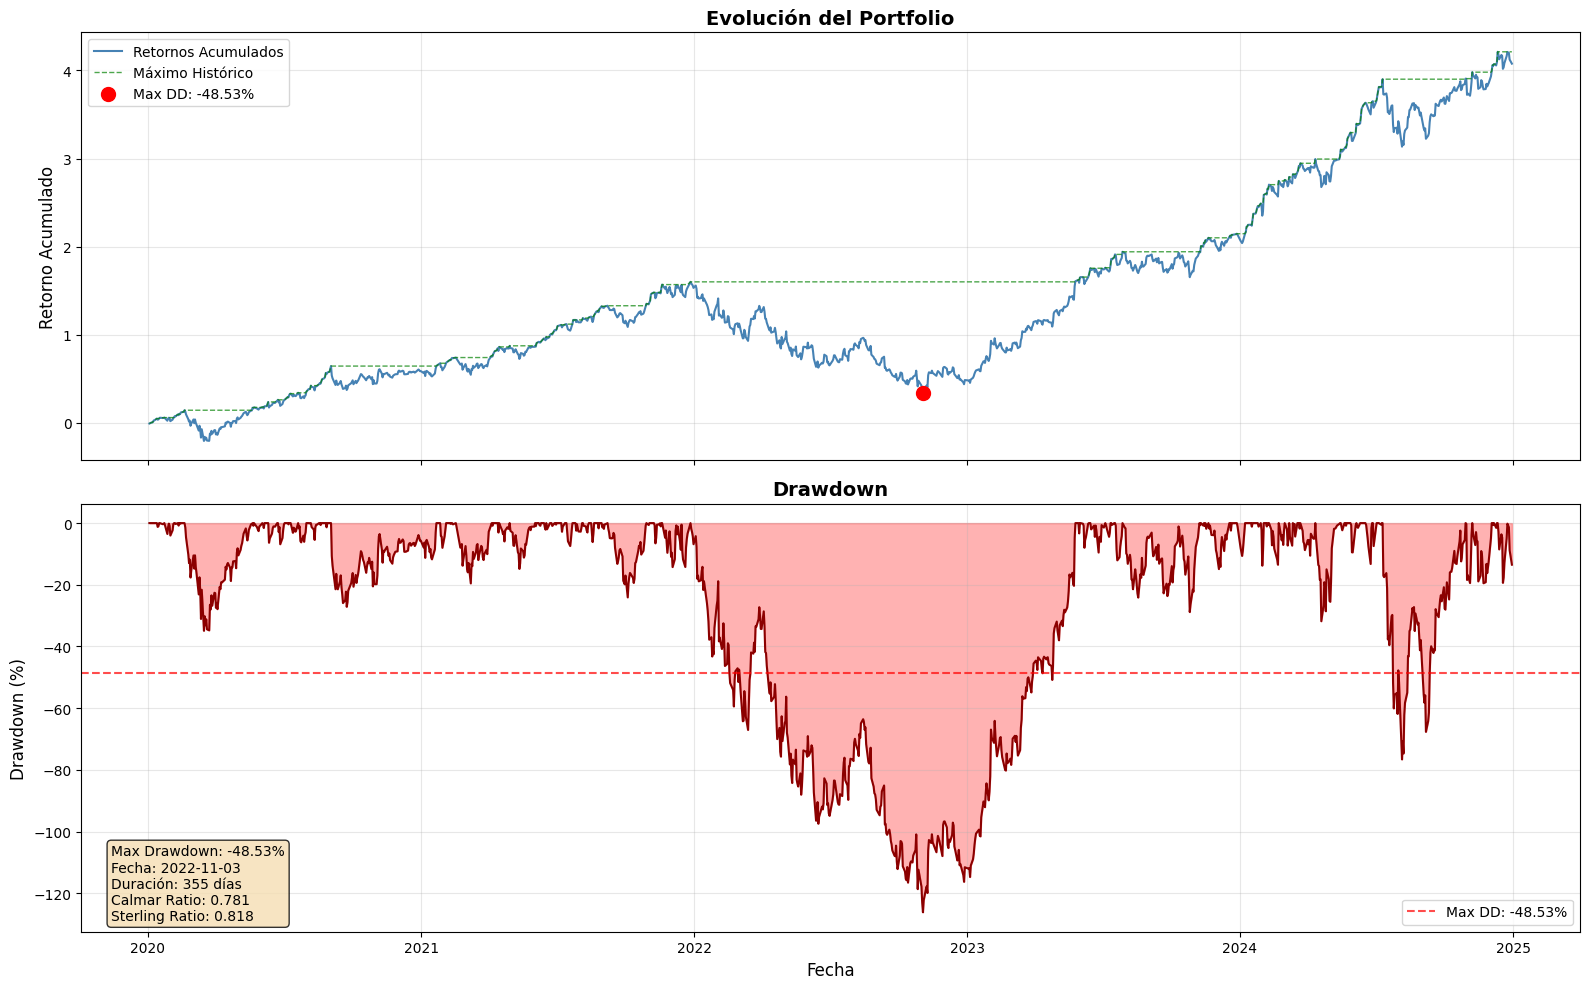

In [21]:
dd_results = drawdown_analyzer.analyze(returns=returns, weights=WEIGHTS)
drawdown_reporter.print_drawdown(dd_results)

fig = drawdown_viz.plot_drawdown_analysis(
    returns=returns,
    weights=WEIGHTS,
    dd_results=dd_results,
    figsize=(16, 10)
)
plt.show()

                  ANÁLISIS DE DISTRIBUCIÓN                  
ASIMETRÍA (Skewness)
  Valor:                     -0.180
  Interpretación:          Aproximadamente simétrica
CURTOSIS (Excess Kurtosis)
  Valor:                      4.771
  Interpretación:          Leptocúrtica (colas pesadas)
                           -> Mayor riesgo de eventos extremos
TEST DE NORMALIDAD (Jarque-Bera)
  Estadístico JB:           1186.11
  p-value:                   0.0000
  Distribución normal:     [NO]


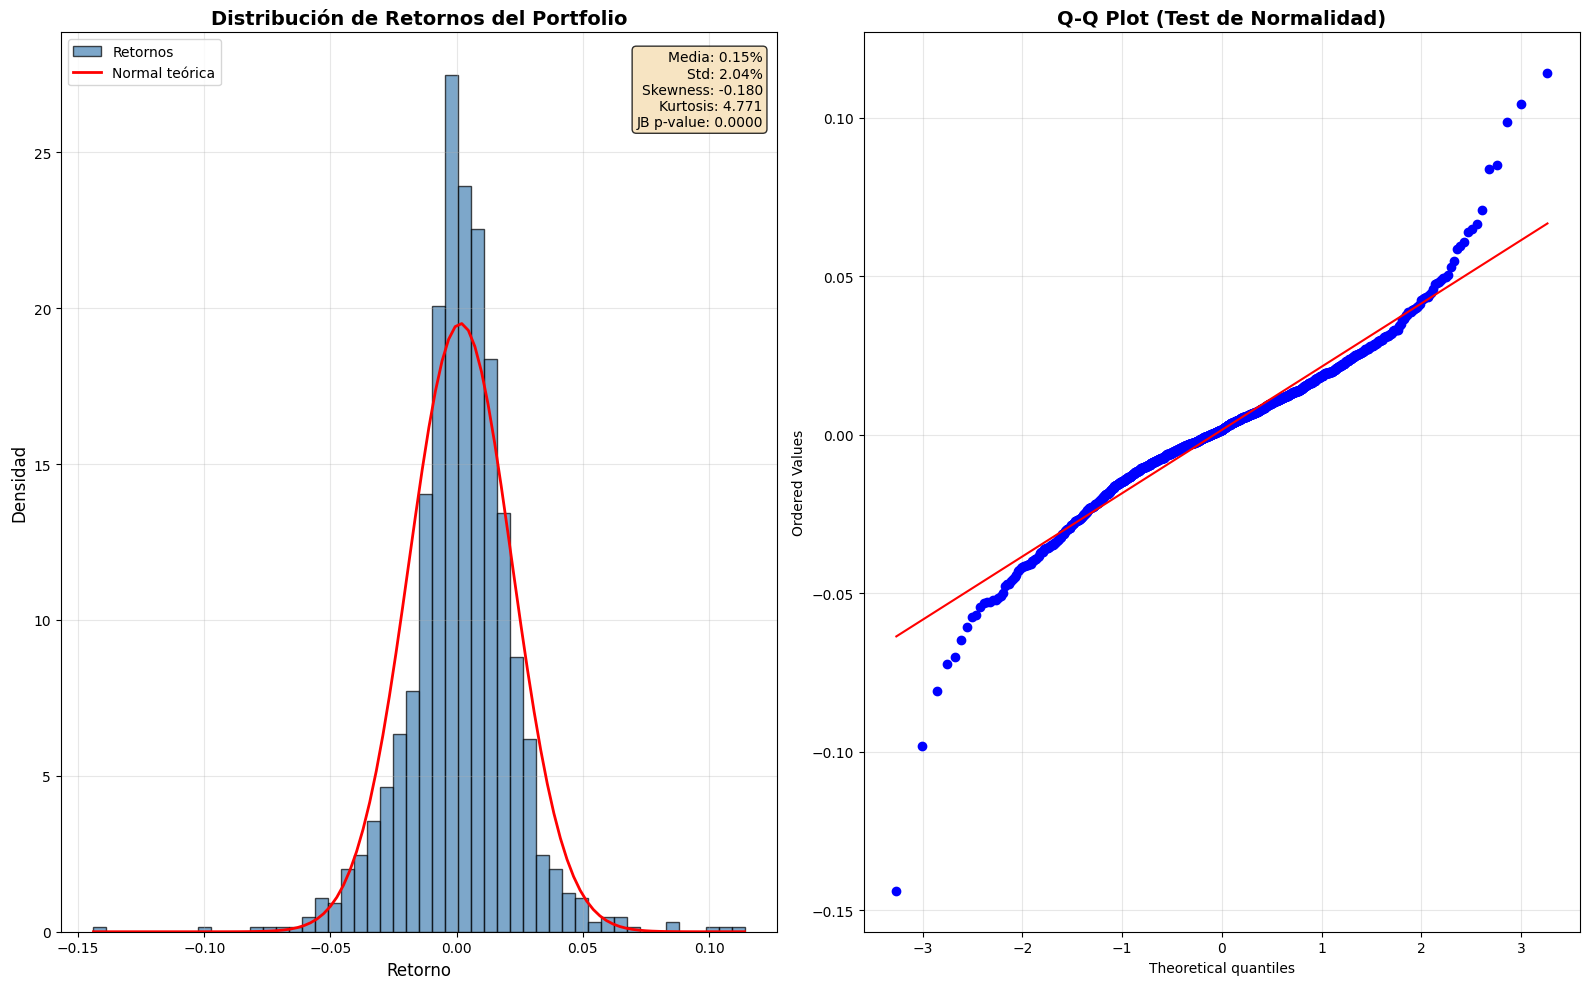

In [22]:
dist_results = dist_analyzer.analyze(returns=returns, weights=WEIGHTS)
dist_reporter.print_distribution(dist_results)

fig = dist_viz.plot_distribution_analysis(
    returns=returns,
    weights=WEIGHTS,
    dist_results=dist_results,
    figsize=(16, 10)
)
plt.show()

In [23]:
benchmark_results = benchmark_analyzer.analyze(
    returns=returns,
    weights=WEIGHTS,
    benchmark_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)

benchmark_reporter.print_benchmark_analysis(benchmark_results)

                   ANÁLISIS VS BENCHMARK                    
TRACKING ERROR
  Tracking Error (diario):      1.12%
  Tracking Error (anual):      17.78%
  Interpretación:          Alta desviación del benchmark
INFORMATION RATIO
  Information Ratio:           1.331
  Interpretación:          Excelente - supera al benchmark
BETA
  Beta:                        1.309
  R²:                          0.741
  Correlación:                 0.861
  Interpretación:          Alta sensibilidad (agresivo)
ALPHA (Jensen)
  Alpha (anualizado):          20.66%
  Retorno cartera:             37.90%
  Retorno benchmark:           14.23%
  Retorno esperado (CAPM):     17.24%
  Interpretación:          Excelente - supera expectativas


                           MÉTRICAS ROLLING                           
                RESUMEN DE MÉTRICAS ROLLING                 
SHARPE RATIO ROLLING
  Promedio:                   1.235
  Mínimo:                    -1.375
  Máximo:                     3.055
  Último:                     2.001
SORTINO RATIO ROLLING
  Promedio:                   1.987
  Mínimo:                    -2.114
  Máximo:                     6.030
  Último:                     2.856


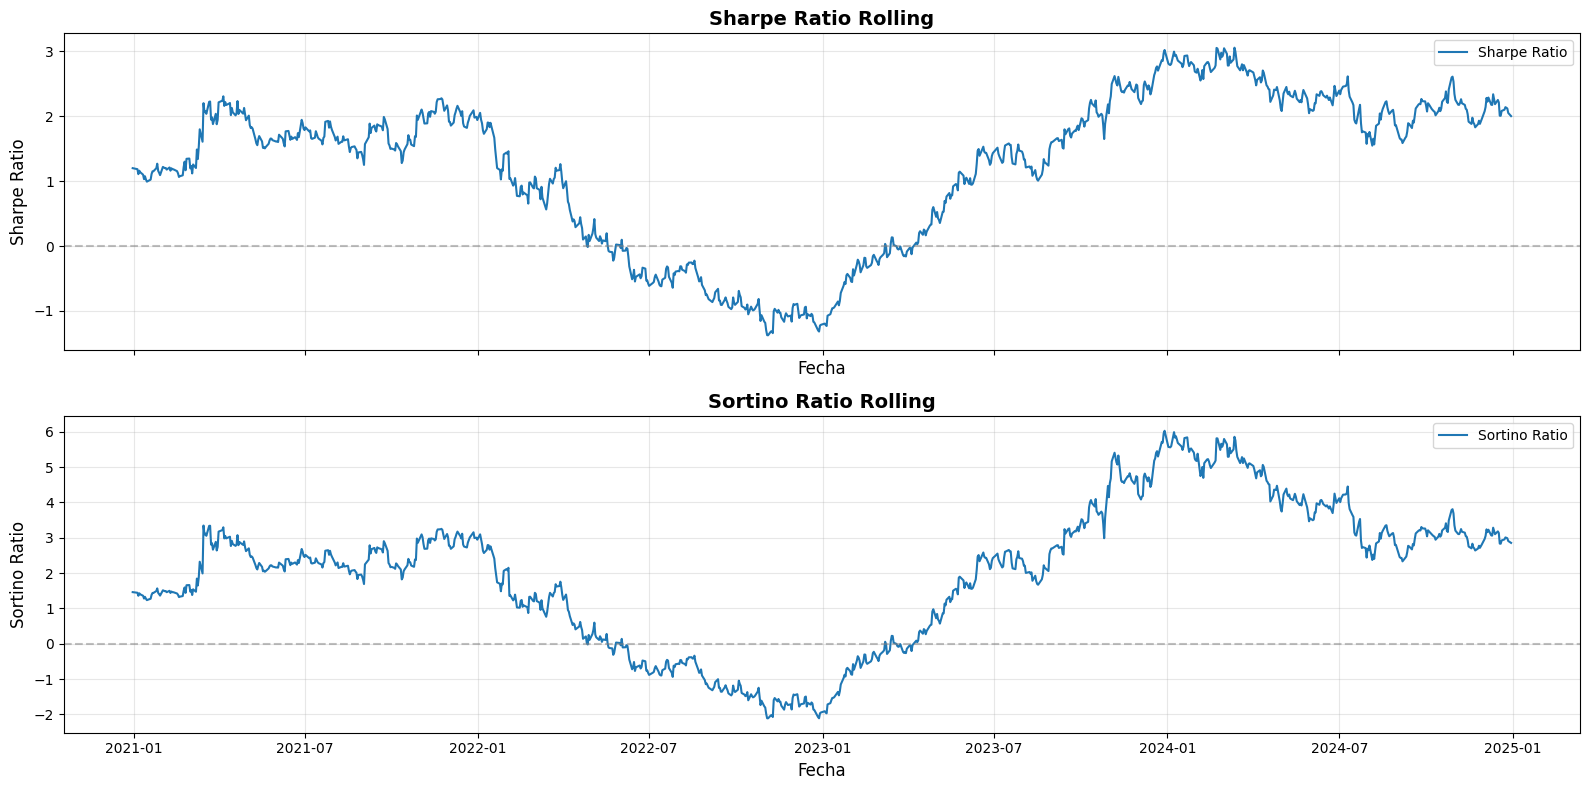

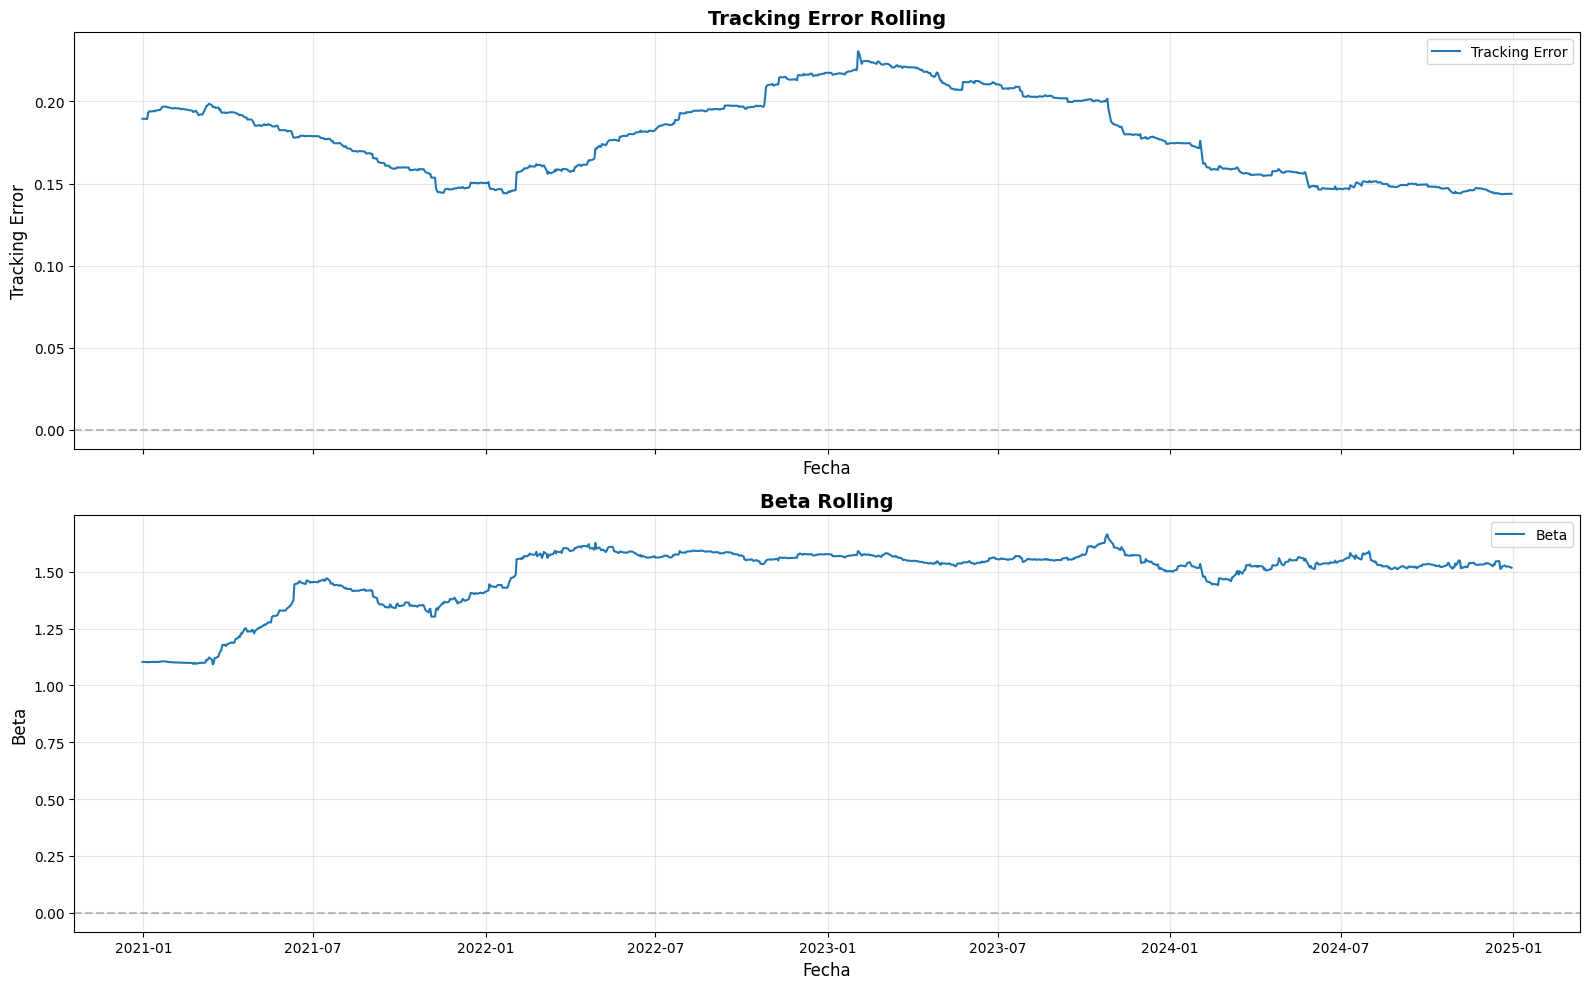

In [24]:
rolling_ratios = ratio_analyzer.calculate_rolling(
    returns=returns,
    weights=WEIGHTS,
    risk_free_rate=RISK_FREE_RATE,
    window=ROLLING_WINDOW
)

rolling_benchmark = benchmark_analyzer.analyze_rolling(
    returns=returns,
    weights=WEIGHTS,
    benchmark_returns=benchmark_returns,
    window=ROLLING_WINDOW
)

print("MÉTRICAS ROLLING".center(70))
ratio_reporter.print_rolling_summary(rolling_ratios)
fig1 = ratio_viz.plot_rolling_ratios(rolling_ratios, figsize=(16, 8))
plt.show()
fig2 = benchmark_viz.plot_rolling_benchmark(rolling_benchmark, figsize=(16, 10))
plt.show()

                  ANÁLISIS DE CORRELACIÓN                   
MATRIZ DE CORRELACIÓN
        META   AAPL  GOOGL   NVDA   MSFT
META   1.000  0.563  0.641  0.535  0.620
AAPL   0.563  1.000  0.649  0.606  0.748
GOOGL  0.641  0.649  1.000  0.594  0.746
NVDA   0.535  0.606  0.594  1.000  0.682
MSFT   0.620  0.748  0.746  0.682  1.000

ESTADÍSTICAS DE CORRELACIÓN
  Correlación promedio:       0.638
  Correlación máxima:         0.748
  Correlación mínima:         0.535
  Desviación estándar:        0.067
PARES MÁS CORRELACIONADOS
  AAPL - MSFT:   0.748
  GOOGL - MSFT:   0.746
  NVDA - MSFT:   0.682
PARES MENOS CORRELACIONADOS
  META - NVDA:   0.535
  META - AAPL:   0.563
  GOOGL - NVDA:   0.594


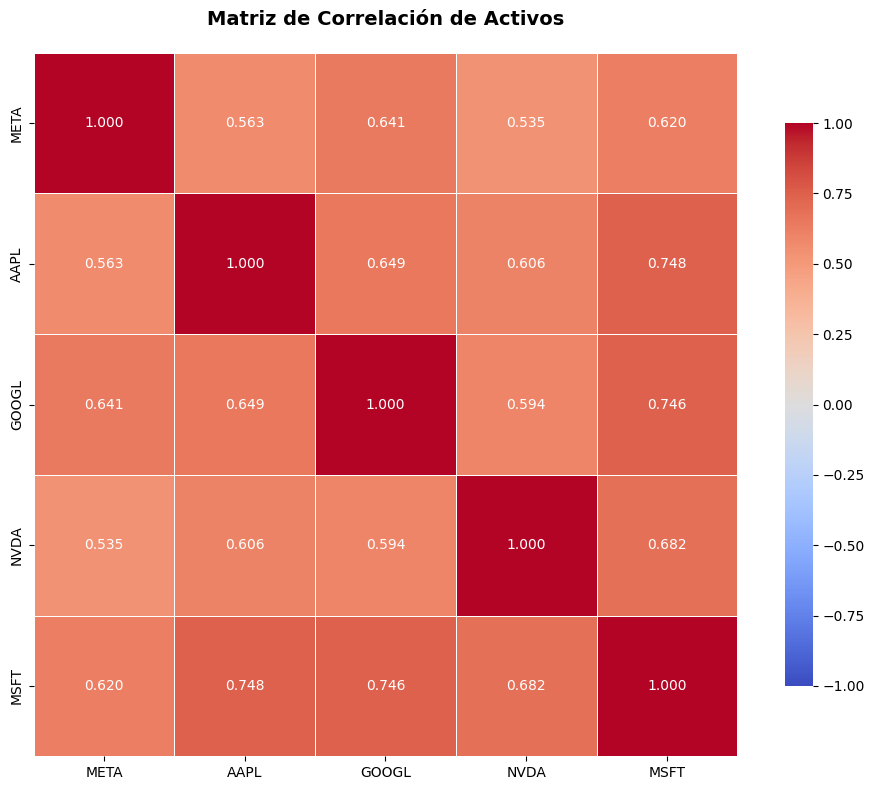

In [29]:
corr_results = correlation_analyzer.analyze(returns=returns)
correlation_reporter.print_correlation_summary(corr_results)  

fig, ax = plt.subplots(figsize=(10, 8))
import seaborn as sns
sns.heatmap(
    corr_results['correlation_matrix'], 
    annot=True, 
    fmt='.3f',  
    cmap='coolwarm', 
    center=0,
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.5,  
    cbar_kws={"shrink": 0.8},  
    ax=ax
)
ax.set_title('Matriz de Correlación de Activos', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [31]:
# ==============================================================================
# CELL 11: RESUMEN CONSOLIDADO
# ==============================================================================
print("\n" + "="*80)
print("RESUMEN DEL ANÁLISIS".center(80))
print("="*80)

print(f"\n📊 PORTAFOLIO: {', '.join(TICKERS)}")
print(f"⚖️  PESOS: Equal-weighted ({WEIGHTS[0]:.1%} cada uno)")
print(f"📅 PERIODO: {returns.index[0].date()} a {returns.index[-1].date()} ({len(returns)} días)")

print(f"\n💰 RENDIMIENTO:")
print(f"  Retorno anual:           {annual_return*100:>8.2f}%")
print(f"  Volatilidad anual:       {annual_vol*100:>8.2f}%")
print(f"  Sharpe Ratio:            {sharpe:>8.3f}")

print(f"\n📉 RIESGO:")
print(f"  Max Drawdown:            {dd_results['max_drawdown']*100:>8.2f}%")
print(f"  VaR (95%, histórico):    {var_es_results[0.95]['historical']['var_daily_pct']:>8.2f}%")
print(f"  ES (95%, histórico):     {var_es_results[0.95]['historical']['es_daily_pct']:>8.2f}%")

print(f"\n📊 VS BENCHMARK ({BENCHMARK_NAME}):")
print(f"  Alpha (anual):           {benchmark_results['alpha_annual']*100:>8.2f}%")
print(f"  Beta:                    {benchmark_results['beta']:>8.3f}")
print(f"  Tracking Error (anual):  {benchmark_results['tracking_error_annual']*100:>8.2f}%")
print(f"  Information Ratio:       {benchmark_results['information_ratio']:>8.3f}")

print(f"\n📈 CALIDAD:")
print(f"  Calmar Ratio:            {dd_results['calmar_ratio']:>8.3f}")
print(f"  Sortino Ratio:           {rolling_ratios['sortino_rolling'].iloc[-1]:>8.3f}")
print(f"  Normalidad (JB test):    {'❌ Rechazada' if dist_results['jb_p_value'] < 0.05 else '✅ Aceptada'}")  # ✅ Corregido



                              RESUMEN DEL ANÁLISIS                              

📊 PORTAFOLIO: META, AAPL, GOOGL, NVDA, MSFT
⚖️  PESOS: Equal-weighted (20.0% cada uno)
📅 PERIODO: 2020-01-03 a 2024-12-30 (1256 días)

💰 RENDIMIENTO:
  Retorno anual:              37.90%
  Volatilidad anual:          32.46%
  Sharpe Ratio:               1.029

📉 RIESGO:
  Max Drawdown:              -48.53%
  VaR (95%, histórico):       -3.32%
  ES (95%, histórico):        -4.65%

📊 VS BENCHMARK (SP500):
  Alpha (anual):              20.66%
  Beta:                       1.309
  Tracking Error (anual):     17.78%
  Information Ratio:          1.331

📈 CALIDAD:
  Calmar Ratio:               0.781
  Sortino Ratio:              2.856
  Normalidad (JB test):    ❌ Rechazada
